# S0 — Rede base IEEE123 (sem EVCS, BESS ou V2G)

Este notebook descreve **como o alimentador funciona** e calcula o caso base S0: configuração elétrica, topologia com NetworkX, parâmetros das linhas (R, X, L, C) e perfil de tensão ao longo do dia.

- Fluxo de potência: `pandapower.runpp_3ph` (trifásico desequilibrado), cargas PQ/I/Z e curva diária de `configs/ieee123.yaml`.
- Mesmo cálculo pela linha de comando: `python -m integration.s0_study --output results/s0` (CSVs, figuras e `summary.json`).
- É uma **aproximação** do IEEE123 no pandapower; as limitações estão no fim e em `data/ieee123/README.md`. Não é validação contra os resultados IEEE publicados.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src'))

import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from network.topology import (feeder_graph, energized, bus_table, graph_metrics, line_table,
                              linecode_table, electrical_inventory)
from network.ieee123_loader import read_ieee123_data
from integration.s0_study import (run_s0, summary, plot_topology, plot_voltage_map,
                                  plot_voltage_profile, plot_daily, plot_linecodes)
pd.set_option('display.precision', 4)
data = read_ieee123_data()

## 1. Como a rede funciona

O IEEE123 é um **alimentador de distribuição radial de 4,16 kV, 60 Hz**. A energia entra pela subestação e segue pelos ramos até as cargas:

1. **Subestação (barra 150):** fonte ideal de 1,0 pu. Logo na saída está o **reg1**, um regulador trifásico que eleva a tensão do alimentador inteiro (tap +7 ≈ +4,4%).
2. **Tronco trifásico:** leva a maior parte da potência. Dele saem **ramais mono e bifásicos**, por isso as fases ficam desequilibradas.
3. **Mais três reguladores:** o reg2 (fase A) e o reg3 (fases A e C) corrigem ramais; o **reg4** (trifásico, barra 160) eleva a tensão de toda a região leste, onde fica a barra 67.
4. **Chaves:** seis fechadas e **duas abertas** (sw7 e sw8). Abertas, elas mantêm a rede radial; fechadas, criariam dois laços. São os pontos de **reconfiguração**.
5. **Capacitores:** quatro bancos (750 kvar no total) fornecem reativo e ajudam a sustentar a tensão.
6. **Transformador xfm1:** 150 kVA, 4,16/0,48 kV, sem carga no caso original.
7. **Cargas:** 91 cargas ligadas em estrela ou delta. Cada uma é **potência constante (PQ)**, **corrente constante (I)** ou **impedância constante (Z)**, isto é, consome mais ou menos conforme a tensão.

As tabelas abaixo saem diretamente dos dados do caso.

In [2]:
inv = electrical_inventory(data)
inv['totals']

frequency_hz          60
source_bus           150
nominal_kv          4.16
load_kw           3490.0
load_kvar         1920.0
capacitor_kvar     750.0
dtype: object

In [3]:
inv['regulators']  # razão = 1 + 0,625% × tap; o pandapower usa a média dos taps de cada banco

,id,from_bus,to_bus,phases,taps,ratio_pu,mean_tap_used,sn_kva
0,reg1,150,150r,ABC,"[7, 7, 7]","[1.04375, 1.04375, 1.04375]",7.0000,5000.0
1,reg2,9,9r,A,[-1],[0.99375],-1.0000,2000.0
2,reg3,25,25r,AC,"[0, -1]","[1.0, 0.99375]",-0.5000,4000.0
3,reg4,160,160r,ABC,"[8, 1, 5]","[1.05, 1.00625, 1.03125]",4.6667,6000.0


In [4]:
inv['loads_by_model']

,connection,model_name,count,p_kw,q_kvar
0,delta,I (constant current),3,245.0,180.0
1,delta,PQ (constant power),1,40.0,20.0
2,delta,Z (constant impedance),3,140.0,100.0
3,wye,I (constant current),12,460.0,250.0
4,wye,PQ (constant power),58,1895.0,970.0
5,wye,Z (constant impedance),14,710.0,400.0


In [5]:
inv['loads_by_phase']  # estrela: fase; delta: ramo entre fases (AB, BC, CA)

,connection,phase_or_branch,p_kw,q_kvar
0,delta,AB,180.0,125.0
1,delta,BC,105.0,75.0
2,delta,CA,140.0,100.0
3,wye,A,1135.0,575.0
4,wye,ABC,315.0,225.0
5,wye,B,705.0,365.0
6,wye,C,910.0,455.0


In [6]:
display(inv['capacitors']); display(inv['switches']); inv['transformer']

,id,bus,phases,q_kvar,kv
0,c83,83,ABC,600.0,4.160
1,c88a,88,A,50.0,2.402
2,c90b,90,B,50.0,2.402
3,c92c,92,C,50.0,2.402


,id,from_bus,to_bus,phases,closed
0,sw1,150r,149,ABC,True
1,sw2,13,152,ABC,True
2,sw3,18,135,ABC,True
3,sw4,60,160,ABC,True
4,sw5,97,197,ABC,True
5,sw6,61,61s,ABC,True
6,sw7,151,300,ABC,False
7,sw8,54,94,A,False


,id,from_bus,to_bus,kv,sn_kva,connection,r_percent,x_percent,model_in_pandapower
0,xfm1,61s,610,4.16/0.48,150.0,Dd0,1.27,2.72,YNyn equivalent


## 2. Topologia com NetworkX

`feeder_graph()` monta um `networkx.Graph` com **todas as barras como nós** e **cada elemento de dois terminais como aresta** (linhas, chaves, reguladores e o transformador), com os atributos elétricos. A figura usa as coordenadas originais do IEEE123.

`energized(g)` remove as chaves abertas: o resultado é a rede realmente resolvida, que precisa ser uma **árvore** (radial).

In [7]:
g = feeder_graph(data)
metrics = graph_metrics(g)
pd.Series({k: v for k, v in metrics.items() if k != 'main_path'})

buses                                130
edges                                131
line_count                           118
switch_count                           8
regulator_count                        4
transformer_count                      1
open_switches                          2
energized_is_tree                   True
loops_if_open_switches_closed          2
end_buses                             41
max_hops                              25
total_line_km                    11.8796
farthest_bus                          96
farthest_km                       1.8974
dtype: object

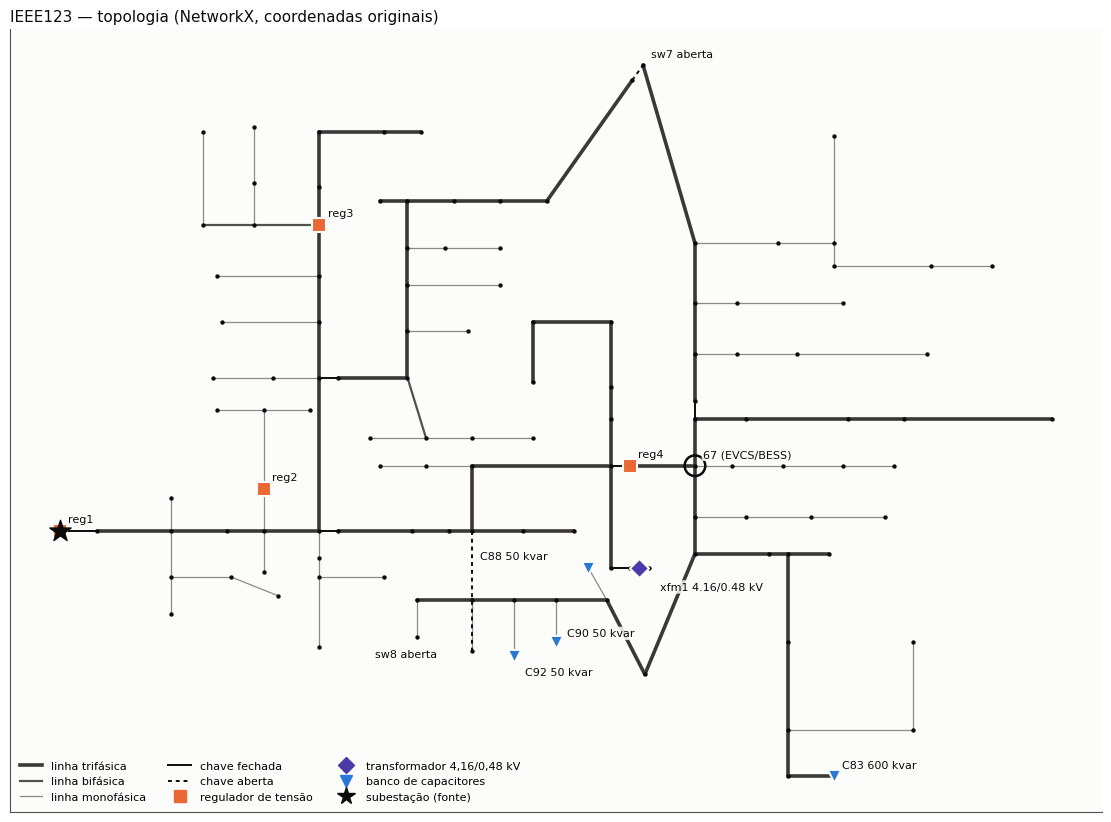

In [8]:
plot_topology({'graph': g, 'buses': bus_table(g)})
plt.show()

O grafo também serve para análise. Por exemplo: o caminho elétrico da subestação até a barra 67 (onde estão EVCS e BESS), a distância percorrida e os equipamentos no caminho.

In [9]:
radial = energized(g)
path = nx.shortest_path(radial, '150', '67')
km = nx.path_weight(radial, path, weight='length_km')
equipment = [radial.edges[u, v]['id'] for u, v in zip(path, path[1:]) if radial.edges[u, v]['kind'] != 'line']
print(f"150 → 67: {len(path)-1} trechos, {km:.3f} km, passando por {equipment}")
print(' → '.join(path))

150 → 67: 15 trechos, 1.029 km, passando por ['reg1', 'sw1', 'sw2', 'sw4', 'reg4']

150 → 150r → 149 → 1 → 7 → 8 → 13 → 152 → 52 → 53 → 54 → 57 → 60 → 160 → 160r → 67

In [10]:
buses = bus_table(g)
buses.sort_values('distance_km', ascending=False).head(8)  # barras mais distantes da subestação

,bus,phases,vn_kv,x,y,distance_km,hops,parent,degree,load_kw,load_kvar,capacitor_kvar
101,96,B,4.16,2025.0,925.0,1.8974,24,95,1,20.0,10.0,0.0
121,114,A,4.16,5125.0,2925.0,1.8898,25,113,1,20.0,10.0,0.0
91,85,C,4.16,4700.0,900.0,1.8745,23,84,1,40.0,20.0,0.0
100,95,ABC,4.16,2025.0,1125.0,1.8364,23,93,2,20.0,10.0,0.0
99,94,A,4.16,2325.0,850.0,1.8288,23,93,1,40.0,20.0,0.0
120,113,A,4.16,4800.0,2925.0,1.7907,24,112,2,40.0,20.0,0.0
97,92,C,4.16,2550.0,825.0,1.7678,22,91,1,40.0,20.0,50.0
118,111,A,4.16,4275.0,3625.0,1.7678,23,110,1,20.0,10.0,0.0


## 3. Parâmetros das linhas: resistência, reatância, indutância e capacitância

Cada linha usa uma das **12 configurações** do IEEE123. A fonte traz, por configuração, matrizes de fase **R**, **X** (Ω) e **C** (nF) por 1000 pés; aqui viram valores por km.

- **Próprio (diagonal):** impedância de cada condutor. **Mútuo (fora da diagonal):** acoplamento entre fases.
- **Indutância:** L = X / (2π·60). É a mesma informação da reatância, em mH.
- **Sequências (o que o pandapower usa):** Z1 = Zpróprio − Zmútuo e Z0 = Zpróprio + 2·Zmútuo. Nas configurações mono e bifásicas o modelo despreza o acoplamento mútuo.

Exemplo: matrizes da configuração 1 (Ω/km, mH/km, nF/km).

In [11]:
code1 = data['linecodes']['1']
kft = 1 / .3048
phases = ['A', 'B', 'C']
for name, key, scale in (('R (Ω/km)', 'rmatrix', kft), ('X (Ω/km)', 'xmatrix', kft),
                         ('L (mH/km)', 'xmatrix', kft / (2*np.pi*60) * 1e3), ('C (nF/km)', 'cmatrix', kft)):
    print(name); display(pd.DataFrame(np.asarray(code1[key]) * scale, index=phases, columns=phases).round(4))

R (Ω/km)

,A,B,C
A,0.2843,0.0969,0.0954
B,0.0969,0.2899,0.0982
C,0.0954,0.0982,0.2868


X (Ω/km)

,A,B,C
A,0.6698,0.3117,0.2392
B,0.3117,0.6513,0.2632
C,0.2392,0.2632,0.6618


L (mH/km)

,A,B,C
A,1.7768,0.8269,0.6344
B,0.8269,1.7277,0.6982
C,0.6344,0.6982,1.7555


C (nF/km)

,A,B,C
A,9.3560,-3.0193,-1.1508
B,-3.0193,9.8577,-1.9193
C,-1.1508,-1.9193,8.8955


In [12]:
lc = linecode_table(data)
lc[['linecode', 'phases', 'lines', 'total_km', 'r_self_ohm_km', 'x_self_ohm_km', 'x_mutual_ohm_km',
    'l_self_mh_km', 'r1_ohm_km', 'x1_ohm_km', 'l1_mh_km', 'r0_ohm_km', 'x0_ohm_km', 'c1_nf_km', 'x1_over_r1']]

,linecode,phases,lines,total_km,r_self_ohm_km,x_self_ohm_km,x_mutual_ohm_km,l_self_mh_km,r1_ohm_km,x1_ohm_km,l1_mh_km,r0_ohm_km,x0_ohm_km,c1_nf_km,x1_over_r1
0,1,3,13,1.0439,0.2870,0.6610,0.2714,1.7533,0.1902,0.3896,1.0335,0.4807,1.2037,11.3996,2.0487
1,2,3,8,0.8230,0.2870,0.6610,0.2714,1.7533,0.1902,0.3896,1.0335,0.4807,1.2037,11.3996,2.0487
2,3,3,14,1.9202,0.2870,0.6610,0.2714,1.7533,0.1902,0.3896,1.0335,0.4807,1.2037,11.3996,2.0487
3,4,3,6,0.5410,0.2870,0.6610,0.2714,1.7533,0.1902,0.3896,1.0335,0.4807,1.2037,10.1200,2.0487
4,5,3,1,0.1676,0.2870,0.6610,0.2714,1.7533,0.1902,0.3896,1.0335,0.4807,1.2037,11.3996,2.0487
5,6,3,13,1.1278,0.2870,0.6610,0.2714,1.7533,0.1902,0.3896,1.0335,0.4807,1.2037,11.3996,2.0487
6,7,2,2,0.1905,0.2856,0.6658,0.2392,1.7662,0.2856,0.6658,1.7662,0.2856,0.6658,8.4765,2.3317
7,8,2,1,0.1981,0.2856,0.6658,0.2392,1.7662,0.2856,0.6658,1.7662,0.2856,0.6658,8.4765,2.3317
8,9,1,22,2.0879,0.8259,0.8373,0.0000,2.2210,0.8259,0.8373,2.2210,0.8259,0.8373,7.4487,1.0138
9,10,1,12,1.1430,0.8259,0.8373,0.0000,2.2210,0.8259,0.8373,2.2210,0.8259,0.8373,7.4487,1.0138


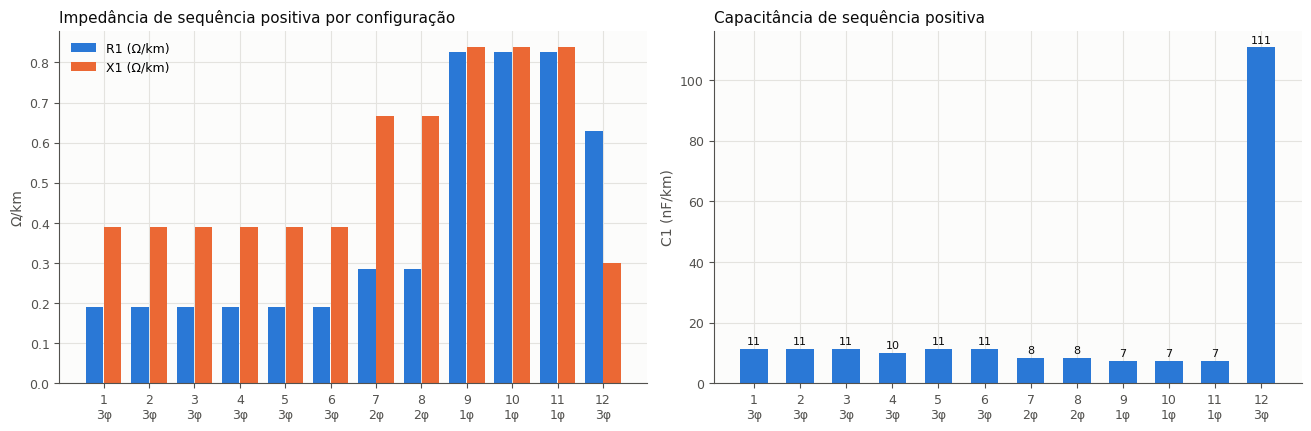

In [13]:
plot_linecodes(lc)
plt.show()

**Leitura:**
- As configurações **1 a 6** usam o mesmo condutor aéreo e diferem só na **posição das fases** no poste. A média de sequência apaga essa diferença, então elas ficam iguais no modelo.
- Ramais **monofásicos (9–11)** têm R por km cerca de 4 vezes e X cerca de 2 vezes os do tronco: condutor mais fino. É onde a tensão cai mais por quilômetro.
- A configuração **12** é **cabo subterrâneo**: capacitância cerca de 10 vezes maior e X/R abaixo de 1.

Por linha, com comprimento e impedância total:

In [14]:
lines = line_table(data)
lines.sort_values('z1_ohm', ascending=False).head(10)

,line,from_bus,to_bus,phases,linecode,length_km,r1_ohm_km,x1_ohm_km,r0_ohm_km,x0_ohm_km,c1_nf_km,r1_ohm,x1_ohm,z1_ohm,l1_mh,c1_nf
104,l103,103,104,C,11,0.2134,0.8259,0.8373,0.8259,0.8373,7.4487,0.1762,0.1786,0.2509,0.4739,1.5893
83,l83,81,84,C,11,0.2057,0.8259,0.8373,0.8259,0.8373,7.4487,0.1699,0.1723,0.2420,0.4569,1.5325
111,l110,110,111,A,9,0.1753,0.8259,0.8373,0.8259,0.8373,7.4487,0.1448,0.1467,0.2061,0.3893,1.3055
107,l106,106,107,B,10,0.1753,0.8259,0.8373,0.8259,0.8373,7.4487,0.1448,0.1467,0.2061,0.3893,1.3055
23,l23,23,24,C,11,0.1676,0.8259,0.8373,0.8259,0.8373,7.4487,0.1385,0.1404,0.1972,0.3723,1.2487
21,l21,21,22,B,10,0.1600,0.8259,0.8373,0.8259,0.8373,7.4487,0.1322,0.1340,0.1882,0.3554,1.1919
113,l112,112,113,A,9,0.1600,0.8259,0.8373,0.8259,0.8373,7.4487,0.1322,0.1340,0.1882,0.3554,1.1919
29,l29,27,33,A,9,0.1524,0.8259,0.8373,0.8259,0.8373,7.4487,0.1259,0.1276,0.1792,0.3385,1.1352
42,l42,42,43,B,10,0.1524,0.8259,0.8373,0.8259,0.8373,7.4487,0.1259,0.1276,0.1792,0.3385,1.1352
85,l85,84,85,C,11,0.1448,0.8259,0.8373,0.8259,0.8373,7.4487,0.1196,0.1212,0.1703,0.3216,1.0784


## 4. Fluxo de potência S0

O S0 roda as 24 horas da curva diária (`load_multipliers` em `configs/ieee123.yaml`), só com as cargas originais. A **ponta** é a hora de maior potência na subestação, com carga 100% da nominal; o **vale** é a de menor. Leva cerca de 30 s.

In [15]:
study = run_s0(ROOT / 'configs')
result = summary(study)
pd.Series({k: v for k, v in result.items() if k != 'graph'})

peak_time                    2026-01-01 18:00:00-06:00
valley_time                  2026-01-01 03:00:00-06:00
peak_source_kw                                3618.079
peak_source_kvar                             1317.8279
daily_energy_kwh                            66474.1181
peak_losses_kw                                 93.0853
daily_losses_kwh                             1345.2713
peak_vmin_pu                                    0.9978
peak_vmin_bus                                     65.A
peak_vmax_pu                                    1.0437
day_vmin_pu                                     0.9978
day_vmax_pu                                     1.0713
buses_below_0.95_at_peak                             0
buses_above_1.05_any_hour                           52
max_line_loading_pct                          142.8719
max_loaded_line                                   l115
dtype: object

### Perfil de tensão

Cada ponto é uma fase de uma barra, posicionada pela **distância elétrica da subestação**; os segmentos ligam cada barra ao seu pai na árvore. Os **degraus verticais** são reguladores (comprimento zero): o reg1 em 0 km e o reg4 em 0,92 km. A barra 150, em 1,00 pu, é a fonte ideal antes do reg1. Tracejado: faixa ANSI C84.1 A, de 0,95 a 1,05 pu.

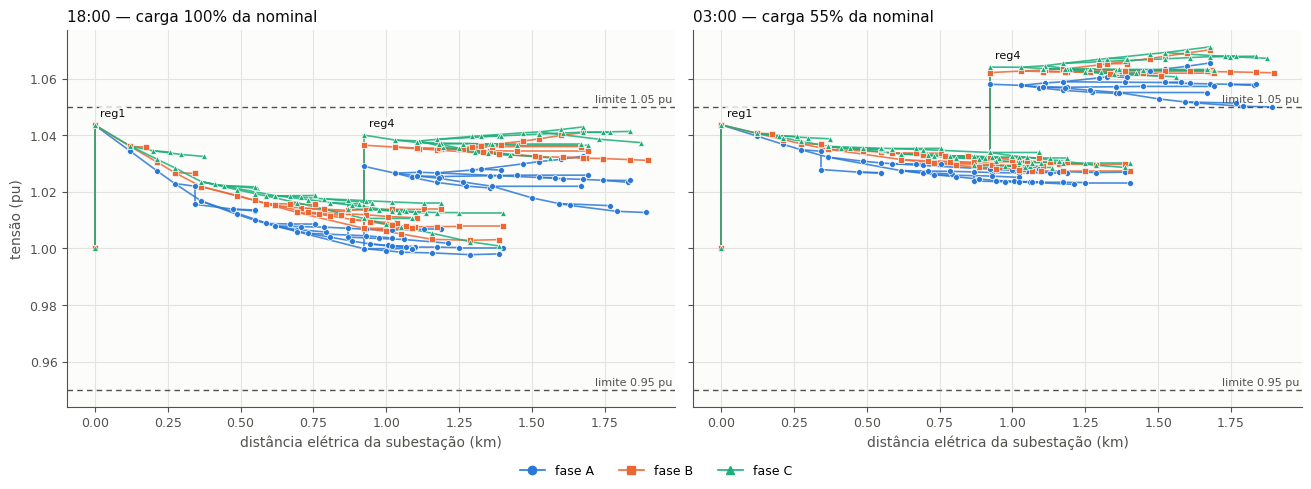

In [16]:
plot_voltage_profile(study)
plt.show()

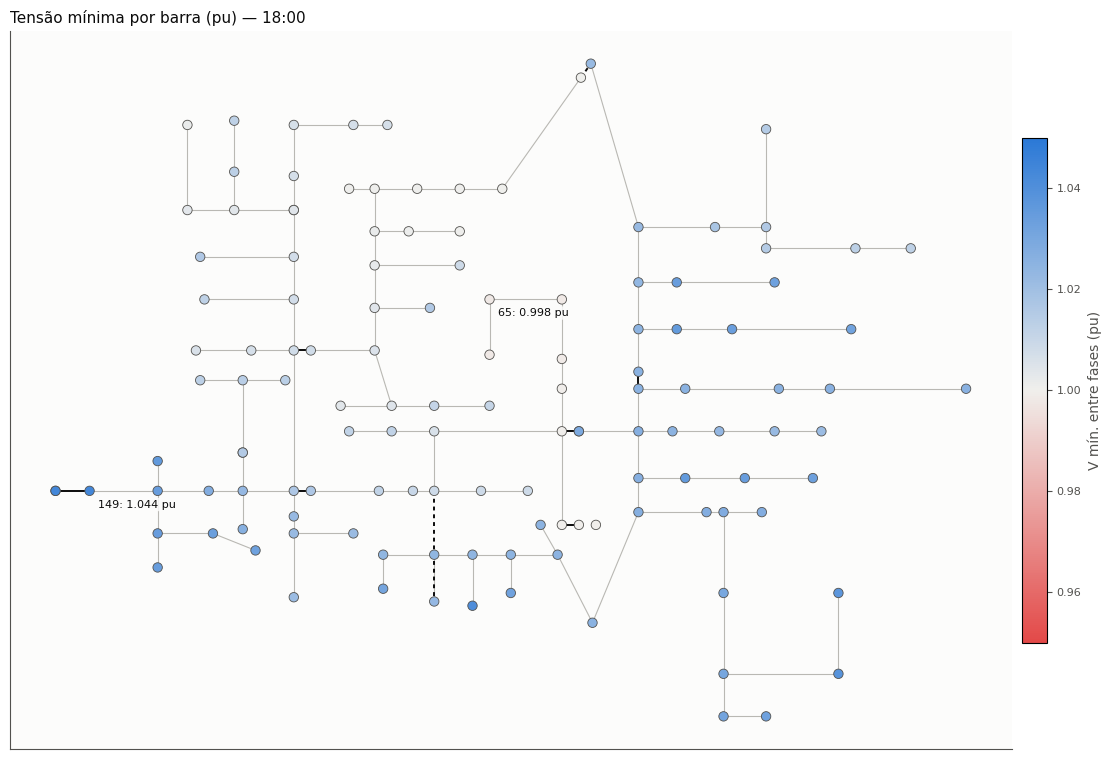

In [17]:
plot_voltage_map(study)
plt.show()

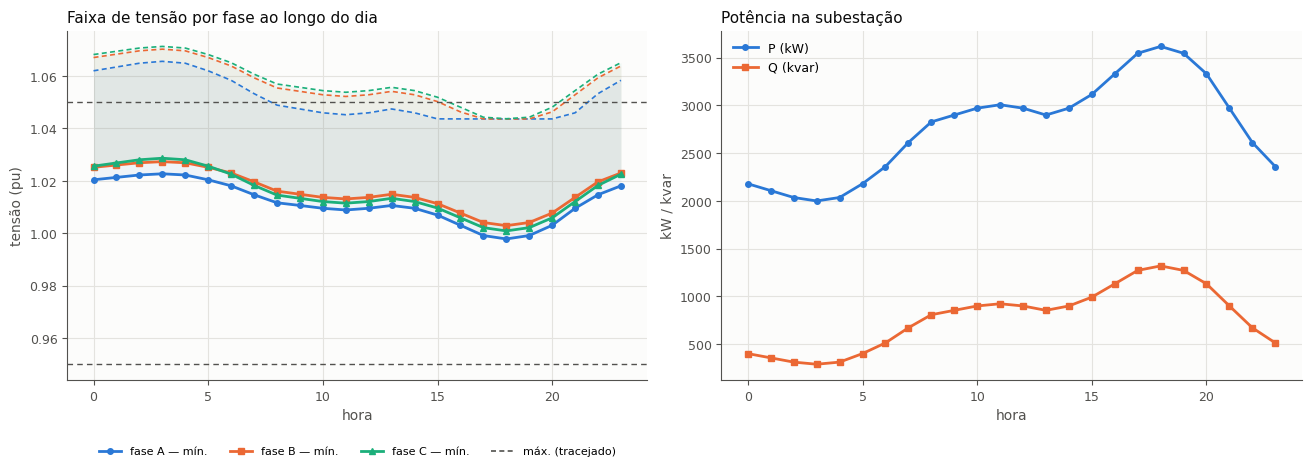

In [18]:
plot_daily(study)
plt.show()

### Carregamento e perdas na ponta
O limite térmico de 400 A por linha é uma **hipótese** do modelo, não a ampacidade IEEE.

In [19]:
b = study['flow']['branches']
b = b[b.physical_phase & (b.time == study['peak'])]
loading = b.pivot_table(index='line', columns='phase', values='current_a').round(1)
loading['loading_max_pct'] = b.groupby('line').loading_pct.max().round(1)
loading['loss_kw'] = b.groupby('line').loss_kw.sum().round(2)
loading.sort_values('loading_max_pct', ascending=False).head(10)

phase,A,B,C,loading_max_pct,loss_kw
line,,,,,
l115,571.5,449.8,520.6,142.9,18.55
l3,553.5,440.8,475.5,138.4,12.64
l7,544.5,440.8,475.5,136.1,8.31
l10,517.1,420.0,465.6,129.3,11.49
reg1,596.3,471.8,541.5,85.9,0.00
l116,311.0,258.3,272.0,77.8,5.51
l52,293.2,258.3,272.0,73.3,2.63
l53,275.4,258.3,272.0,68.9,1.57
l58,266.4,231.8,272.0,68.0,8.64


## 5. O que o S0 mostra

- **Sem subtensão:** na ponta, a menor tensão é cerca de 0,998 pu (barra 65, fase A). O reg1 eleva o alimentador inteiro e compensa a queda ao longo do tronco.
- **Sobretensão em carga leve:** em 19 das 24 horas há barras acima de 1,05 pu, até cerca de 1,07 pu de madrugada. **Todas ficam a jusante do reg4**. No IEEE123 original os reguladores têm controle automático; aqui os taps são **fixos** (média 8/1/5 → +2,9%), então a tensão não desce quando a carga cai. É uma limitação do modelo, não do alimentador.
- **Tronco carregado:** os primeiros trechos (l115, l3, l7, l10) passam de 400 A na ponta, com até cerca de 570 A na fase A. Isso indica o desequilíbrio entre fases e mostra que a hipótese de 400 A precisa ser revista antes de qualquer conclusão térmica.
- **Perdas:** cerca de 93 kW na ponta (2,6% da potência da subestação) e cerca de 1,35 MWh no dia.
- **Para os próximos cenários:** a barra 67 fica logo depois do reg4, onde a tensão já é alta. Uma carga EVCS ali tende a **aliviar** a sobretensão, e a descarga de BESS ou V2G tende a **agravá-la**.

## Limitações
Linhas trifásicas representadas por médias de sequência, sem acoplamento assimétrico; ramais mono e bifásicos sem mútuas; reguladores com taps fixos (média por banco); transformador Dd0 trocado por um equivalente YNyn; limite de 400 A assumido; sem comparação com as tensões IEEE publicadas. Detalhes em `data/ieee123/README.md`.